In [108]:
import sunpy.map
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt

def Action_position_From_fits(fits_file_path,is_show=True):
    
    """
    处理一个活动区的FITS文件，显示其内容（可选），并返回一些关键坐标。
    
    参数:
        fits_file_path (str): FITS文件的路径。
        is_show (bool): 是否显示处理后的地图，默认为True。
        
    返回:
        dict: 包含地图中心、左下角和右上角的世界坐标的字典。
    """
    
    map = sunpy.map.Map(fits_file_path)
    

    if is_show:
        fig = plt.figure(figsize=(5, 7))
        ax = fig.add_subplot(projection=map)
        m_map.plot(axes=ax)
        plt.title('Original Map')
        plt.show()

    return {
        'center_pixel_world': map.center,
        'bottom_left_world':  map.bottom_left_coord,
        'top_right_world':   map.top_right_coord,
    }

def CEA_reproject(fits_file_path, shape=(2048, 4096), is_show=True):
    """
    将给定的FITS文件重新投影到CEA投影，并可选地显示结果。
    
    参数:
        fits_file_path (str): FITS文件路径。
        shape (tuple): 输出地图的形状，默认为(2048, 4096)。
        is_show (bool): 是否显示处理后的地图，默认为True。
        
    返回:
        sunpy.map.GenericMap: 重新投影后的地图。
    """
    original_map = sunpy.map.Map(fits_file_path)
    
    # 创建CEA投影的头信息
    cea_header = make_heliographic_header(original_map.date, original_map.observer_coordinate, shape, projection_code='CEA', frame='stonyhurst')
    
    # 使用sunpy的reproject_to方法重新投影地图
    outmap = original_map.reproject_to(cea_header)
    
    if is_show:
        fig = plt.figure(figsize=(10, 5))
        ax = fig.add_subplot(projection=outmap)
        outmap.plot(axes=ax)  # 修正为使用outmap而非m_map
        plt.title('Reprojected Map')
        plt.show()
    
    return outmap

def CEAmap_Crop(CEAmap, center_world, size=(300, 300), is_show=True):
    """
    裁剪CEA投影地图中指定中心点和尺寸的部分。
    
    参数:
        CEAmap (sunpy.map.GenericMap): 需要裁剪的地图。
        center_world (SkyCoord): 裁剪区域的中心坐标。
        size (tuple): 裁剪区域的宽度和高度，默认为(300, 300)。
        is_show (bool): 是否显示裁剪后的图像，默认为True。
        
    返回:
        numpy.ndarray: 裁剪后的数据数组。
    """
    center_pixel_x, center_pixel_y = CEAmap.world_to_pixel(center_world)
    
    center_pixel_x, center_pixel_y = center_pixel_x.to_value(u.pix), center_pixel_y.to_value(u.pix)
    
    width, height = size
    
    bottom_left_pixel_x = int(float(center_pixel_x) - width / 2)
    bottom_left_pixel_y = int(float(center_pixel_y) - height / 2)
    top_right_pixel_x = int(float(center_pixel_x) + width / 2)
    top_right_pixel_y = int(float(center_pixel_y) + height / 2)
    
    print(bottom_left_pixel_x, top_right_pixel_x, bottom_left_pixel_y, top_right_pixel_y)
    
    # 获取裁剪后的数据
    out_put_data = CEAmap.data[bottom_left_pixel_y:top_right_pixel_y, bottom_left_pixel_x:top_right_pixel_x]
    
    new_meta = CEAmap.meta.copy()
    new_meta['crpix1'] -= bottom_left_pixel_x 
    new_meta['crpix2'] -= bottom_left_pixel_y
    
    cropped_map = sunpy.map.Map(out_put_data, new_meta)
    cropped_map.plot_settings = CEAmap.plot_settings  
    
    if is_show:
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(projection=cropped_map)
        cropped_map.plot(axes=ax)
        plt.title('Cropped Map')
        plt.show()
    
    return cropped_map
    



See https://docs.sunpy.org/en/stable/how_to/fix_map_metadata.html for how to fix metadata before loading it with sunpy.map.Map.
See https://fits.gsfc.nasa.gov/fits_standard.html for the FITS unit standards. [sunpy.map.mapbase]
See https://docs.sunpy.org/en/stable/how_to/fix_map_metadata.html for how to fix metadata before loading it with sunpy.map.Map.
See https://fits.gsfc.nasa.gov/fits_standard.html for the FITS unit standards. [sunpy.map.mapbase]


2793 3093 557 857


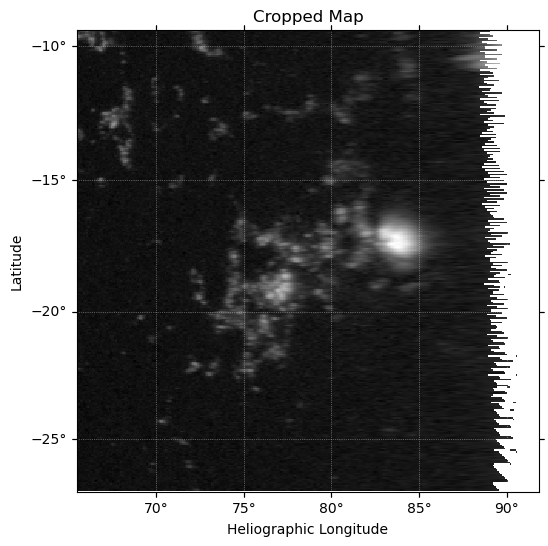

2793 3093 557 857


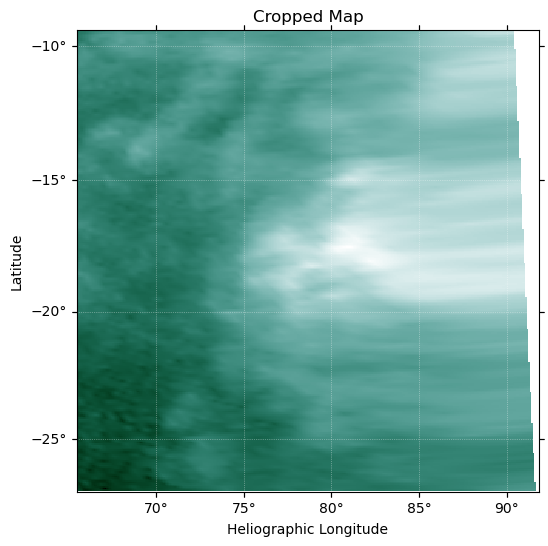

In [115]:
fits_file_path = '/home/zhangbi/SolarFlares_Web/Code/hmi.B_720s.20140507_000000_TAI.field.fits'

result = Action_position_From_fits(fits_file_path,is_show=False)

## filed_cea
CEAmap = CEA_reproject(fits_file_path,shape=(2048,4096),is_show=False)
out_put = CEAmap_Crop(CEAmap, result["center_pixel_world"], size=(300, 300), is_show=True)

## AIA 
AIA_fits_file_path = '/home/zhangbi/SolarFlares_Web/Code/AIA20140507_0000_0094.fits'
AIA_CEAmap = CEA_reproject(AIA_fits_file_path,shape=(2048,4096),is_show=False)
AIA_out_put = CEAmap_Crop(AIA_CEAmap, result["center_pixel_world"], size=(300, 300), is_show=True)


In [116]:
AIA_out_put.save("1.fits")

In [ ]:
from astropy.io import fits

fits.open("1.fits")[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  300                                                  
NAXIS2  =                  300                                                  
WCSAXES =                    2                                                  
CRPIX1  =               -744.5                                                  
CRPIX2  =                467.5                                                  
CDELT1  =          0.087890625                                                  
CDELT2  =    0.055952909680744                                                  
CUNIT1  = 'deg     '                                                            
CUNIT2  = 'deg     '                                                            
CTYPE1  = 'HGLN-CEA'        

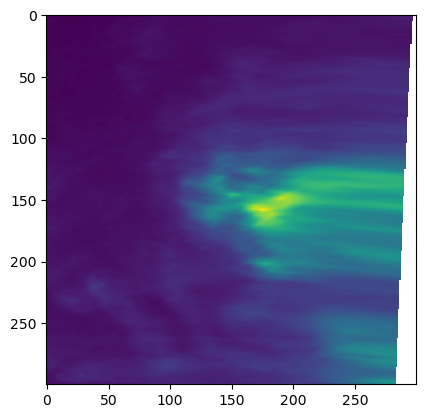

In [124]:
plt.imshow(fits.open("1.fits")[0].data)